In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.info()
df.isnull().sum()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

(2240, 22)

In [5]:
df["Income"]

0       58138.0
1       46344.0
2       71613.0
3       26646.0
4       58293.0
         ...   
2235    61223.0
2236    64014.0
2237    56981.0
2238    69245.0
2239    52869.0
Name: Income, Length: 2240, dtype: float64

In [6]:
imp=SimpleImputer(strategy="mean")
df["Income"]=imp.fit_transform(df[["Income"]])

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [9]:
df["age"]=2026-df["Year_Birth"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [12]:
ref_date=df["Dt_Customer"].max()
df["customer_Tenure_days"]=(ref_date-df["Dt_Customer"]).dt.days

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    2240 non-null   int64         
 1   Year_Birth            2240 non-null   int64         
 2   Education             2240 non-null   object        
 3   Marital_Status        2240 non-null   object        
 4   Income                2240 non-null   float64       
 5   Kidhome               2240 non-null   int64         
 6   Teenhome              2240 non-null   int64         
 7   Dt_Customer           2240 non-null   datetime64[ns]
 8   Recency               2240 non-null   int64         
 9   MntWines              2240 non-null   int64         
 10  MntFruits             2240 non-null   int64         
 11  MntMeatProducts       2240 non-null   int64         
 12  MntFishProducts       2240 non-null   int64         
 13  MntSweetProducts  

In [14]:
df["total_purchase"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_Tenure_days,total_purchase
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    2240 non-null   int64         
 1   Year_Birth            2240 non-null   int64         
 2   Education             2240 non-null   object        
 3   Marital_Status        2240 non-null   object        
 4   Income                2240 non-null   float64       
 5   Kidhome               2240 non-null   int64         
 6   Teenhome              2240 non-null   int64         
 7   Dt_Customer           2240 non-null   datetime64[ns]
 8   Recency               2240 non-null   int64         
 9   MntWines              2240 non-null   int64         
 10  MntFruits             2240 non-null   int64         
 11  MntMeatProducts       2240 non-null   int64         
 12  MntFishProducts       2240 non-null   int64         
 13  MntSweetProducts  

In [17]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [18]:
df["Education"]=df["Education"].replace({
    "Graduation":"Graduate",
    "PhD":"Postgraduate",
    "Master":"Postgraduate",
    "2n Cycle":"UnderGraduate",
    "Basic":"UnderGraduate"
})

In [19]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [20]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_Tenure_days,total_purchase
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [21]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [22]:
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"partner",
    "Together":"partner",
    "Single":"Single",
    "Divorced":"Single",
    "Widow":"Single",
    "Alone":"Single",
    "Absurd":"Single",
    "YOLO":"Single"
})

In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_Tenure_days,total_purchase,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,Single
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,Single
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,partner


In [24]:
df["total_child"]=df["Kidhome"] + df["Teenhome"]

In [25]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_Tenure_days,total_purchase,Living_with,total_child
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,Single,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,Single,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,partner,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,partner,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,partner,1


In [26]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'customer_Tenure_days', 'total_purchase',
       'Living_with', 'total_child'],
      dtype='object')

In [27]:
new_df=df.drop(['ID','Year_Birth','Marital_Status','Kidhome','Teenhome', 'Dt_Customer', 'MntWines', 'MntFruits',
        'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds',],axis=1)

In [28]:
new_df

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_Tenure_days,total_purchase,Living_with,total_child
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,Single,0
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,Single,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,partner,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,partner,1
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,partner,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,partner,1
2236,Postgraduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,partner,3
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,Single,0
2238,Postgraduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,partner,1


In [29]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2240 non-null   object 
 1   Income                2240 non-null   float64
 2   Recency               2240 non-null   int64  
 3   NumDealsPurchases     2240 non-null   int64  
 4   NumWebPurchases       2240 non-null   int64  
 5   NumCatalogPurchases   2240 non-null   int64  
 6   NumStorePurchases     2240 non-null   int64  
 7   NumWebVisitsMonth     2240 non-null   int64  
 8   Complain              2240 non-null   int64  
 9   Response              2240 non-null   int64  
 10  age                   2240 non-null   int64  
 11  customer_Tenure_days  2240 non-null   int64  
 12  total_purchase        2240 non-null   int64  
 13  Living_with           2240 non-null   object 
 14  total_child           2240 non-null   int64  
dtypes: float64(1), int64(

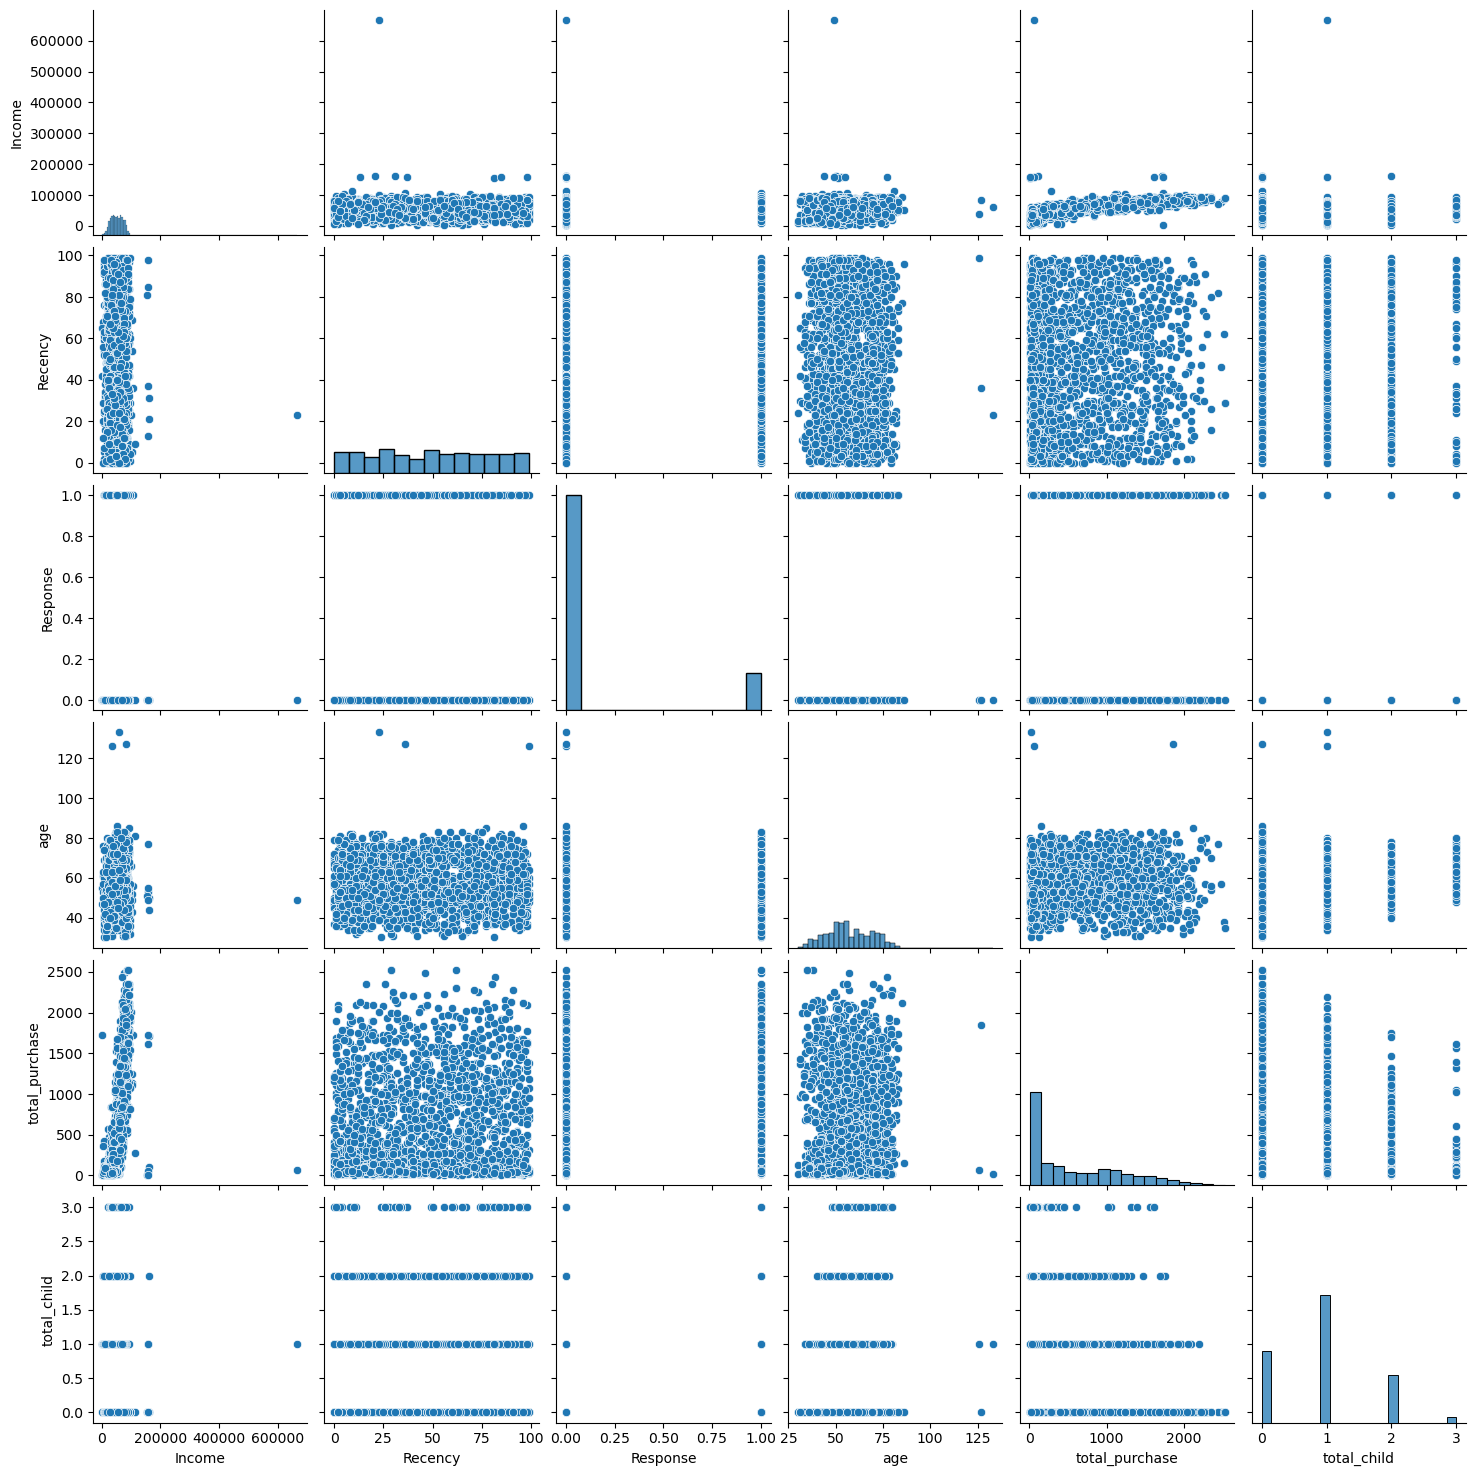

In [30]:
cols=['Income','Recency','Response','age','total_purchase','total_child']

sns.pairplot(new_df[cols])

In [31]:
# remove outliers

print("data size with outliers: ",len(new_df))

new_df=new_df[(new_df["age"] < 90)]
new_df=new_df[(new_df["Income"] < 600_000)]

print("data size without outliers: ",len(new_df))


data size with outliers:  2240
data size without outliers:  2236


In [32]:
# correlation

corr=new_df.corr(numeric_only=True)

<Axes: >

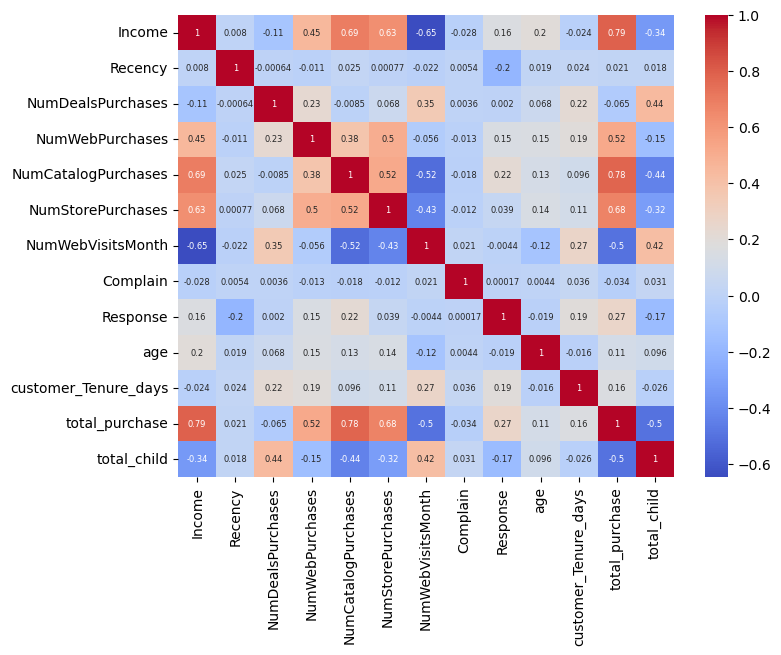

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size':6},
    cmap="coolwarm"
)

In [34]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Education             2236 non-null   object 
 1   Income                2236 non-null   float64
 2   Recency               2236 non-null   int64  
 3   NumDealsPurchases     2236 non-null   int64  
 4   NumWebPurchases       2236 non-null   int64  
 5   NumCatalogPurchases   2236 non-null   int64  
 6   NumStorePurchases     2236 non-null   int64  
 7   NumWebVisitsMonth     2236 non-null   int64  
 8   Complain              2236 non-null   int64  
 9   Response              2236 non-null   int64  
 10  age                   2236 non-null   int64  
 11  customer_Tenure_days  2236 non-null   int64  
 12  total_purchase        2236 non-null   int64  
 13  Living_with           2236 non-null   object 
 14  total_child           2236 non-null   int64  
dtypes: float64(1), int64(12), 

In [35]:
ohe=OneHotEncoder()

cat_cols=["Education","Living_with"]
encoded_cols=ohe.fit_transform(new_df[cat_cols])

encoded_df=pd.DataFrame(encoded_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=new_df.index)
df_encoded=pd.concat([new_df.drop(columns=cat_cols),encoded_df],axis=1)

In [36]:
df_encoded.shape

(2236, 18)

In [37]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_Tenure_days,total_purchase,total_child,Education_Graduate,Education_Postgraduate,Education_UnderGraduate,Living_with_Single,Living_with_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [38]:
X=df_encoded

# scaling

In [39]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# visualize in 2D

In [40]:
from sklearn.decomposition import PCA

pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)



In [41]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

Text(0.5, 0.92, '3d projection')

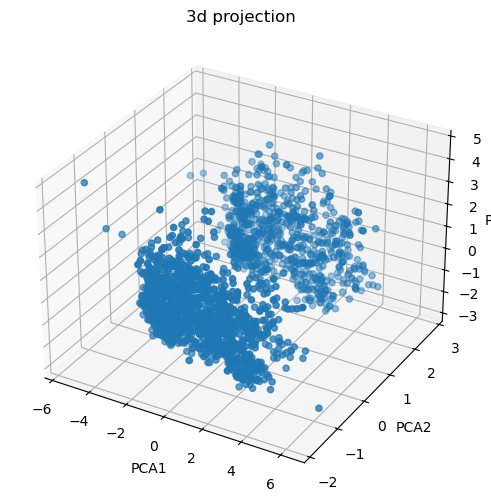

In [42]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

ax.set_title("3d projection")

# analyse k value
# 1.  Elbow method

In [43]:
wcss=[]
from sklearn.cluster import KMeans
from kneed import KneeLocator

for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    # print(kmeans.inertia_)
    wcss.append(kmeans.inertia_)

In [44]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
k_value=knee.elbow

In [45]:
print("best k: ",k_value)

best k:  4


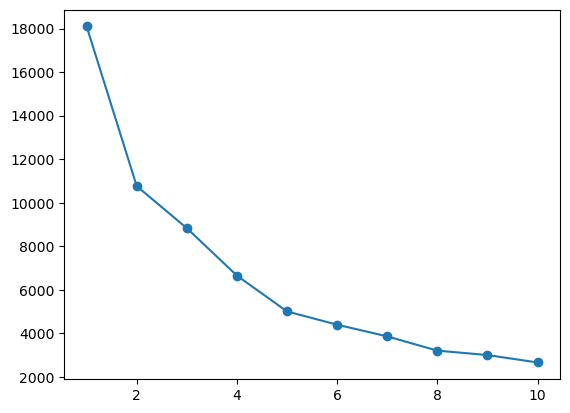

In [46]:
plt.plot(range(1,11),wcss,marker='o')

# 2.silhouette score



In [47]:
from sklearn.metrics import silhouette_score

ss=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)

    ss.append(score)


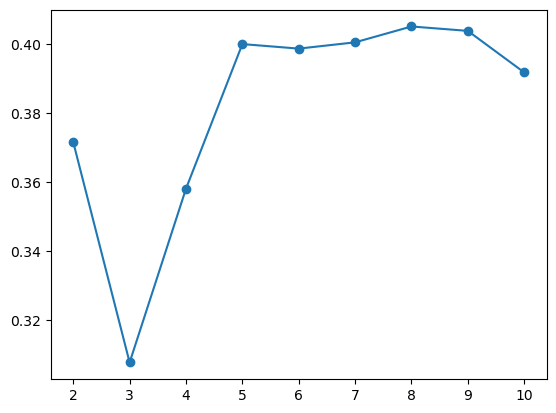

In [48]:
plt.plot(range(2,11),ss,marker='o')

Text(0, 0.5, 'ss')

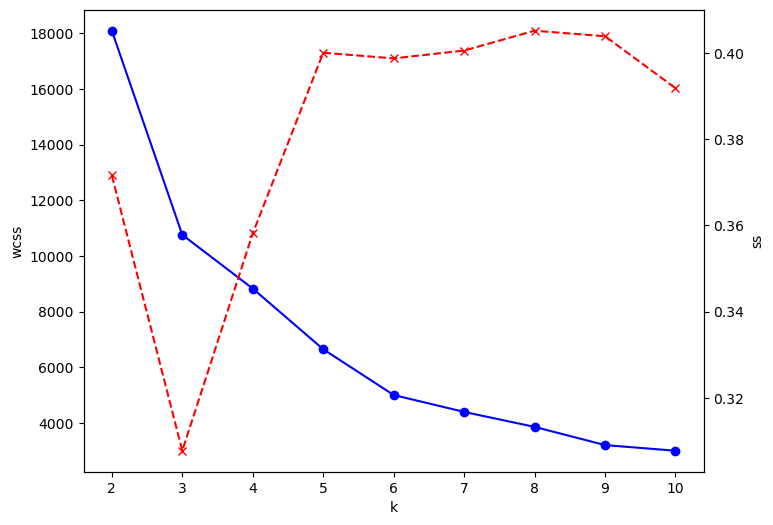

In [49]:
# combine plot

k_range=range(2,11)

fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2=ax1.twinx()
ax2.plot(k_range,ss[:len(k_range)],marker='x',color='red',linestyle="--")
ax2.set_xlabel("k")
ax2.set_ylabel("ss")

# clustering

In [50]:
kmeans=KMeans(n_clusters=4,random_state=42)

label_kmeans=kmeans.fit_predict(X_pca)

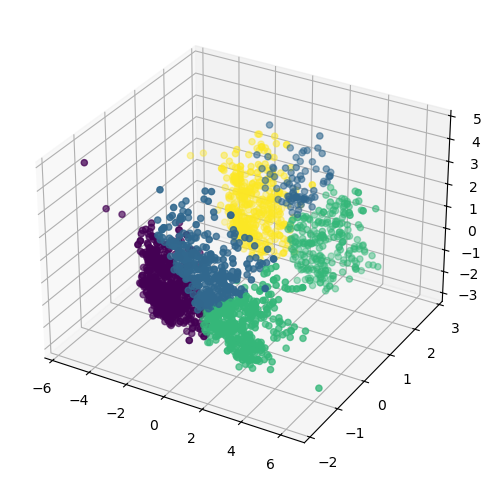

In [51]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label_kmeans)

In [52]:
# agglomerative
from sklearn.cluster import AgglomerativeClustering

agg_clf=AgglomerativeClustering(n_clusters=4,linkage='ward')

labels_agg=agg_clf.fit_predict(X_pca)

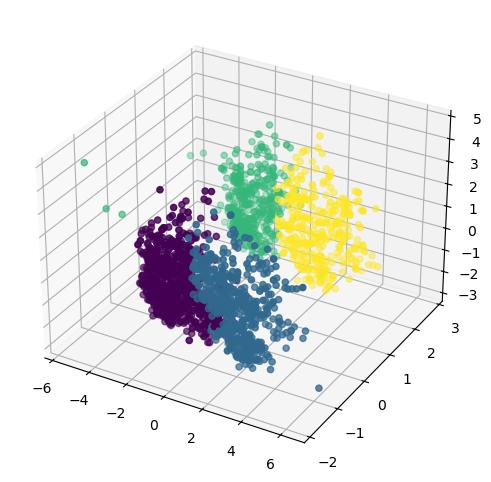

In [53]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

# characterization of clusters



In [54]:

X["cluster"]=labels_agg

In [55]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,customer_Tenure_days,total_purchase,total_child,Education_Graduate,Education_Postgraduate,Education_UnderGraduate,Living_with_Single,Living_with_partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

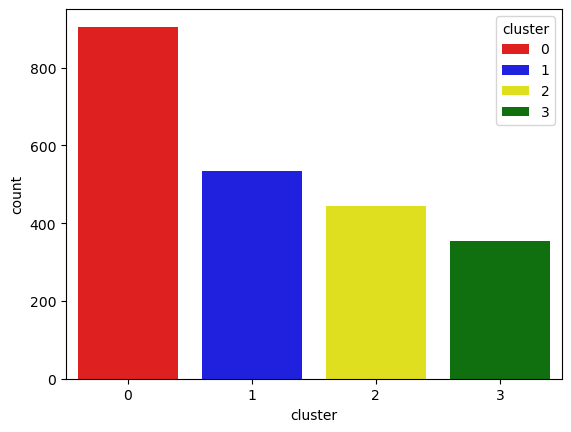

In [56]:
pal=["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

# Income & spending pattern


<Axes: xlabel='total_purchase', ylabel='Income'>

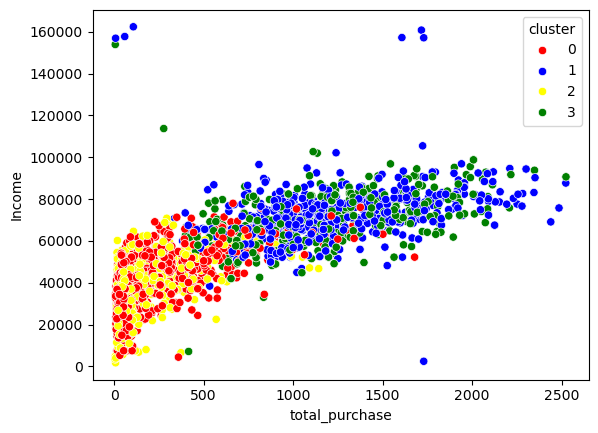

In [57]:
sns.scatterplot(x=X["total_purchase"],y=X["Income"],hue=X["cluster"],palette=pal)

# cluster summary


In [58]:
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39690.146424  48.914917           2.594475         3.153591   
1        72814.930722  49.202247           1.958801         5.687266   
2        36973.792251  48.319820           2.594595         2.713964   
3        70730.038963  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        age  customer_Tenure_days  total_purchase  \
cluster         